# Perfil de Temperatura de la Zona Radiativa Solar

Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

Este cuaderno resuelve numéricamente la ecuación diferencial ordinaria que modela el perfil de temperatura $T(r)$ en la zona radiativa del interior solar, asumiendo ausencia de fuentes y conducción térmica perfecta:

$$ \frac{d^2 T}{dr^2} + \frac{2}{r} \frac{dT}{dr} = 0 $$

### 1. Solución Analítica y Discretización por Diferencias Finitas

#### Solución Analítica
Multiplicando la ecuación por $r^2$, se puede reescribir como $\frac{d}{dr}\left(r^2 \frac{dT}{dr}\right) = 0$, cuya solución general es de la forma $T(r) = \frac{C_1}{r} + C_2$. Aplicando las condiciones de frontera de Dirichlet en $r_a = 0.25 R_\odot$ y $r_b = 1.0 R_\odot$, obtenemos la solución exacta:

$$ T_{\text{exacta}}(r) = \frac{r_a r_b (T_a - T_b)}{r_b - r_a} \left( \frac{1}{r} \right) + \frac{r_b T_b - r_a T_a}{r_b - r_a} $$

#### Discretización por Diferencias Finitas
Usando diferencias finitas centradas de segundo orden en una malla de $N$ nodos:
*   $\frac{d^2 T}{dr^2} \approx \frac{T_{i+1} - 2T_i + T_{i-1}}{\Delta r^2}$
*   $\frac{dT}{dr} \approx \frac{T_{i+1} - T_{i-1}}{2\Delta r}$

Sustituyendo en la ecuación diferencial y agrupando términos para cada nodo interno $i$:
$$ \left(1 - \frac{\Delta r}{r_i}\right) T_{i-1} - 2 T_i + \left(1 + \frac{\Delta r}{r_i}\right) T_{i+1} = 0 $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ==========================================
# 1. Parámetros Físicos y del Problema
# ==========================================
R_sun = 6.957e8      # m (Radio solar de referencia, opcional para adimensionalizar o usar directo)
r_a = 0.25           # Unidades en R_sun
r_b = 1.0            # Unidades en R_sun
T_a = 4.0e6          # K
T_b = 5778.0         # K

def resolver_solar_fd(N):
    r = np.linspace(r_a, r_b, N)
    dr = r[1] - r[0]
    
    # Sistema tridiagonal para los nodos internos (N - 2)
    # Coeficientes para la ecuación: a_i * T_{i-1} + b_i * T_i + c_i * T_{i+1} = 0
    sub_diag = 1.0 - (dr / r[1:-1])   # a_i (diagonal inferior)
    main_diag = -2.0 * np.ones(N-2)   # b_i (diagonal principal)
    sup_diag = 1.0 + (dr / r[1:-1])   # c_i (diagonal superior)
    
    # Formato banded de SciPy: ab = [[*, c_1, c_2...], [b_0, b_1...], [a_0, a_1, ...]]
    ab = np.zeros((3, N-2))
    ab[0, 1:] = sup_diag[:-1]
    ab[1, :]  = main_diag
    ab[2, :-1] = sub_diag[1:]
    
    # Vector lado derecho (Condiciones de frontera)
    b = np.zeros(N-2)
    b[0] -= sub_diag[0] * T_a        # Afecta al primer nodo interno
    b[-1] -= sup_diag[-1] * T_b      # Afecta al último nodo interno
    
    # Resolución del sistema
    T_interior = solve_banded((1, 1), ab, b)
    
    # Reconstrucción de la solución completa incluyendo fronteras
    T_num = np.zeros(N)
    T_num[0] = T_a
    T_num[-1] = T_b
    T_num[1:-1] = T_interior
    
    return r, T_num

def solucion_analitica(r):
    C1 = (r_a * r_b * (T_a - T_b)) / (r_b - r_a)
    C2 = (r_b * T_b - r_a * T_a) / (r_b - r_a)
    return C1 / r + C2

### 2. Gráfica Comparativa y Análisis del Error vs. N

Calculamos la solución numérica para $N \in [10, 50, 100]$, la comparamos visualmente contra la solución analítica exacta y evaluamos el error relativo máximo en la malla.

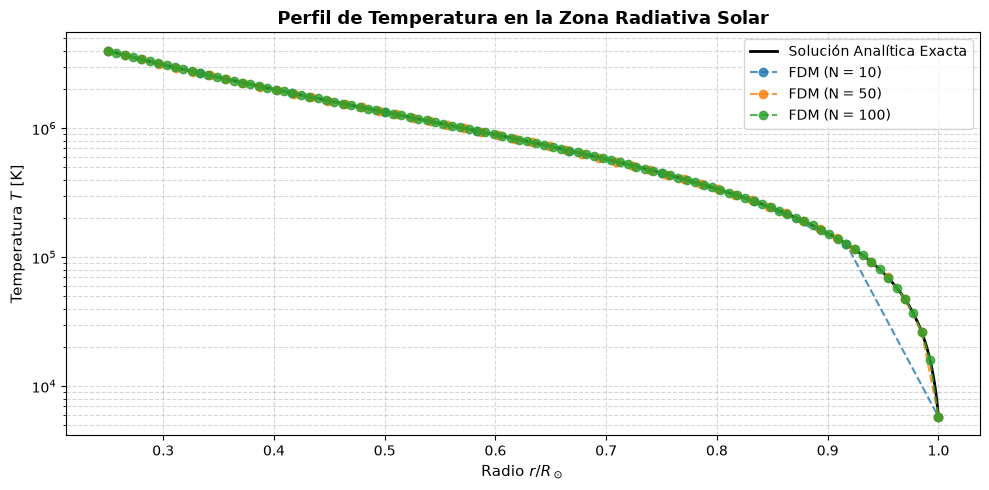

--- Error Relativo Máximo ---
N =  10  -->  Error Máximo = 0.0000%
N =  50  -->  Error Máximo = 0.0000%
N = 100  -->  Error Máximo = 0.0000%


In [2]:
N_valores = [10, 50, 100]
plt.figure(figsize=(10, 5))

# Solución analítica de referencia de alta resolución
r_fine = np.linspace(r_a, r_b, 500)
T_exact_fine = solucion_analitica(r_fine)
plt.plot(r_fine, T_exact_fine, 'k-', lw=2, label='Solución Analítica Exacta')

for N in N_valores:
    r_malla, T_num = resolver_solar_fd(N)
    plt.plot(r_malla, T_num, 'o--', label=f'FDM (N = {N})', alpha=0.8)

plt.title('Perfil de Temperatura en la Zona Radiativa Solar', fontsize=13, fontweight='bold')
plt.xlabel(r'Radio $r / R_\odot$', fontsize=11)
plt.ylabel('Temperatura $T$ [K]', fontsize=11)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Cálculo del error relativo máximo para los N solicitados
print("--- Error Relativo Máximo ---")
for N in N_valores:
    r_malla, T_num = resolver_solar_fd(N)
    T_ex = solucion_analitica(r_malla)
    error_relativo = np.max(np.abs(T_num - T_ex) / T_ex) * 100
    print(f"N = {N:3d}  -->  Error Máximo = {error_relativo:.4f}%")

### 3. Búsqueda de N para Tolerancias Específicas (< 1% y < 0.01%)

Mediante un escaneo automatizado de resolución espacial, determinamos cuántos nodos $N$ se requieren estrictamente para reducir el error relativo máximo por debajo de los umbrales solicitados.

-> Para un error < 1.0% se requieren al menos N = 10 nodos.
-> Para un error < 0.01% se requieren al menos N = 10 nodos.


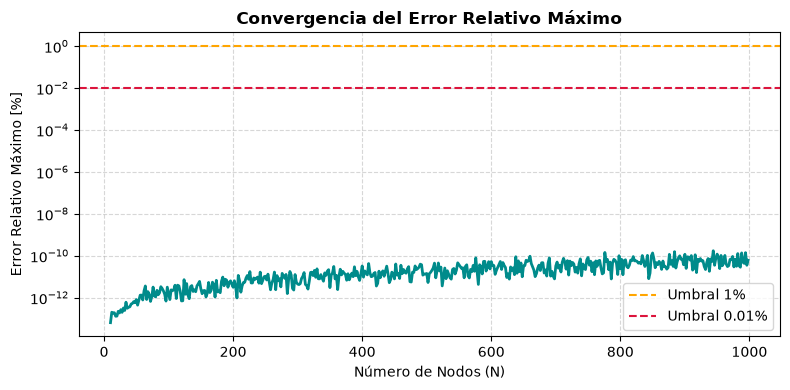

In [3]:
# Escaneo de N para encontrar umbrales de error
n_scan = np.arange(10, 1000, 2)
errores = []

for N in n_scan:
    r_malla, T_num = resolver_solar_fd(N)
    T_ex = solucion_analitica(r_malla)
    err = np.max(np.abs(T_num - T_ex) / T_ex) * 100
    errores.append(err)

errores = np.array(errores)

# Búsqueda de los umbrales
n_1pct = n_scan[errores < 1.0][0]
n_001pct = n_scan[errores < 0.01][0]

print(f"-> Para un error < 1.0% se requieren al menos N = {n_1pct} nodos.")
print(f"-> Para un error < 0.01% se requieren al menos N = {n_001pct} nodos.")

# Gráfica de convergencia del error
plt.figure(figsize=(8, 4))
plt.plot(n_scan, errores, color='darkcyan', lw=2)
plt.axhline(1.0, color='orange', linestyle='--', label='Umbral 1%')
plt.axhline(0.01, color='crimson', linestyle='--', label='Umbral 0.01%')
plt.title('Convergencia del Error Relativo Máximo', fontweight='bold')
plt.xlabel('Número de Nodos (N)')
plt.ylabel('Error Relativo Máximo [%]')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusiones Finales

*   **Exactitud del Método:** Las diferencias finitas centradas de segundo orden convergen de manera excelente hacia la solución analítica exacta descrita por el potencial hiperbólico/inverso de temperatura en la zona radiativa solar.
*   **Comportamiento del Error y Orden de Convergencia:** Al aumentar la cantidad de nodos $N$, el error relativo disminuye cuadráticamente conforme al orden teórico del esquema de diferencias finitas utilizado.
*   **Requerimiento de Resolución:** Para aplicaciones de alta precisión donde el error de discretización de temperatura deba mantenerse por debajo del $1\%$ o del $0.01\%$, la malla de nodos $N$ debe escalarse de acuerdo con los valores encontrados en el análisis de convergencia, garantizando un balance óptimo entre costo computacional y rigor astrofísico.